# Chương 5: Nhận Diện Khuôn Mặt Thời Gian Thực với FaceNet & MTCNN
---

## Mục Tiêu
- Truy cập và thu thập dữ liệu từ webcam bằng OpenCV
- Tích hợp MTCNN để phát hiện khuôn mặt
- Sử dụng FaceNet để trích xuất đặc trưng (embedding) và so sánh khuôn mặt thời gian thực
- Ngưỡng so sánh: similarity > 0.7 → "Matched", similarity < 0.7 → "Unknown"

## Yêu Cầu Thư Viện
```bash
pip install facenet-pytorch torch opencv-python numpy matplotlib Pillow
```

---
## 0. Cài Đặt Thư Viện (Chạy 1 Lần Đầu)
Chạy cell bên dưới nếu chưa cài các thư viện cần thiết.

In [13]:
 #!pip install facenet-pytorch torch opencv-python numpy matplotlib Pillow

---
## 1. Import Thư Viện và Cấu Hình

In [2]:
%matplotlib inline
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1

# Kiểm tra thiết bị (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[*] Thiet bi: {device}')

# Đường dẫn
DATASET_DIR = '../dataset'
OUTPUT_DIR  = '../outputs'
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'[*] Thu muc dataset: {os.path.abspath(DATASET_DIR)}')
print(f'[*] Thu muc output:  {os.path.abspath(OUTPUT_DIR)}')

[*] Thiet bi: cpu
[*] Thu muc dataset: d:\computer_vision_lab\chapters\chapter05_face_recognition\dataset
[*] Thu muc output:  d:\computer_vision_lab\chapters\chapter05_face_recognition\outputs


---
## Phần 1: Truy Cập Webcam và Chụp Ảnh Tham Chiếu

Sử dụng OpenCV để mở webcam và chụp ảnh khuôn mặt tham chiếu. Nhấn **'c'** để chụp, nhấn **'q'** để thoát.

In [3]:
def capture_reference_images(save_dir=DATASET_DIR):
    """Mo webcam, nhan 'c' de chup anh tham chieu, 'q' de thoat."""
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print('[!] Khong the mo webcam! Kiem tra camera.')
        return

    print('[*] Webcam da mo thanh cong!')
    print('[*] Nhan "c" de chup anh tham chieu')
    print('[*] Nhan "q" de thoat')
    print(f'[*] Anh se duoc luu vao: {save_dir}')

    count = 0
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            print('[!] Khong doc duoc frame!')
            break

        # Hien thi huong dan tren frame
        cv2.putText(frame_bgr, "Press 'c' to capture, 'q' to quit",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow('Capture Reference - Chapter 5', frame_bgr)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('c'):
            count += 1
            name = input(f'Nhap ten nguoi cho anh {count}: ').strip().lower().replace(' ', '_')
            if not name:
                name = f'person_{count}'
            filepath = os.path.join(save_dir, f'{name}.jpg')
            cv2.imwrite(filepath, frame_bgr)
            print(f'[OK] Da luu: {filepath}')
        elif key == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f'[OK] Da chup {count} anh tham chieu.')

> **Chạy cell bên dưới để chụp ảnh tham chiếu** (chỉ chạy khi chưa có ảnh trong `dataset/`)

In [4]:
# Bo comment dong duoi de chay:
capture_reference_images()

[*] Webcam da mo thanh cong!
[*] Nhan "c" de chup anh tham chieu
[*] Nhan "q" de thoat
[*] Anh se duoc luu vao: ../dataset
[OK] Da chup 0 anh tham chieu.


---
## Phần 2: Khởi Tạo MTCNN và FaceNet

- **MTCNN**: Phát hiện khuôn mặt với 3 tầng cascade (P-Net, R-Net, O-Net)
- **FaceNet (InceptionResnetV1)**: Trích xuất embedding 512 chiều từ khuôn mặt 160x160

> Lần đầu chạy sẽ tự động tải pre-trained weights (~100MB). Cần kết nối internet!

In [5]:
print('[*] Dang khoi tao MTCNN...')
mtcnn = MTCNN(
    keep_all=True,         # Phat hien tat ca khuon mat trong frame
    device=device,
    min_face_size=40       # Kich thuoc mat toi thieu (pixels)
)
print('[OK] MTCNN da san sang!')

print('[*] Dang khoi tao FaceNet (InceptionResnetV1)...')
model = InceptionResnetV1(
    pretrained='vggface2', # Pre-trained tren VGGFace2
    classify=False,        # Tra ve embedding, khong phan loai
    device=device
).eval()
print('[OK] FaceNet da san sang!')

[*] Dang khoi tao MTCNN...
[OK] MTCNN da san sang!
[*] Dang khoi tao FaceNet (InceptionResnetV1)...
[OK] FaceNet da san sang!


---
## Phần 3: Hàm Trích Xuất Embedding FaceNet

FaceNet yêu cầu:
- Ảnh đầu vào: RGB, kích thước **160×160** pixels
- Chuẩn hóa giá trị pixel về khoảng **[-1, 1]**: `(pixel - 127.5) / 128.0`
- Đầu ra: vector **512 chiều**, chuẩn hóa L2 (`||v|| = 1`)

In [6]:
def extract_embedding(face_img, model, device='cpu'):
    """Trich xuat embedding FaceNet tu anh khuon mat RGB (160, 160, 3).
    
    Tham so:
        face_img: numpy array (160, 160, 3) - anh RGB khuon mat
        model:    InceptionResnetV1 model
        device:   'cpu' hoac 'cuda'
    
    Tra ve:
        numpy array (512,) - embedding da chuan hoa L2
    """
    # Chuyen numpy (H, W, C) -> tensor (C, H, W)
    face_tensor = torch.from_numpy(face_img).permute(2, 0, 1).float()
    
    # Chuan hoa ve [-1, 1]
    face_tensor = (face_tensor - 127.5) / 128.0
    
    # Them batch dimension -> (1, 3, 160, 160)
    face_tensor = face_tensor.unsqueeze(0).to(device)
    
    # Suy luan (khong tinh gradient)
    with torch.no_grad():
        embedding = model(face_tensor)
    
    # Chuyen ve numpy va chuan hoa L2
    embedding = embedding.squeeze(0).cpu().numpy()
    embedding = embedding / np.linalg.norm(embedding)
    
    return embedding

print('[OK] Ham extract_embedding da duoc dinh nghia.')

[OK] Ham extract_embedding da duoc dinh nghia.


---
## Phần 4: Đăng Ký Khuôn Mặt Tham Chiếu

Duyệt tất cả ảnh trong thư mục `dataset/`, phát hiện khuôn mặt bằng MTCNN, trích xuất embedding bằng FaceNet, và lưu vào dictionary `reference_embeddings`.

- Tên người = tên file (không bao gồm phần mở rộng)
- Ví dụ: `nguyen_van_a.jpg` → tên người: `nguyen_van_a`

In [7]:
def register_reference_faces(dataset_dir, mtcnn, model, device='cpu'):
    """Dang ky khuon mat tham chieu tu thu muc dataset.
    
    Tham so:
        dataset_dir: str - duong dan thu muc chua anh tham chieu
        mtcnn:       MTCNN detector
        model:       FaceNet model
        device:      'cpu' hoac 'cuda'
    
    Tra ve:
        dict {ten_nguoi: embedding_vector (512,)}
    """
    reference_embeddings = {}
    
    if not os.path.isdir(dataset_dir):
        print(f'[!] Thu muc "{dataset_dir}" khong ton tai!')
        return reference_embeddings
    
    files = [f for f in os.listdir(dataset_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if not files:
        print('[!] Khong tim thay anh nao trong dataset/!')
        print('[*] Hay chay cell capture_reference_images() de chup anh tham chieu.')
        return reference_embeddings
    
    print(f'[*] Tim thay {len(files)} anh trong dataset/')
    print('='*50)
    
    for filename in files:
        filepath = os.path.join(dataset_dir, filename)
        person_name = os.path.splitext(filename)[0]
        
        # Doc anh
        img_bgr = cv2.imread(filepath)
        if img_bgr is None:
            print(f'[!] Khong doc duoc: {filename}')
            continue
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        
        # Phat hien khuon mat bang MTCNN
        boxes, probs = mtcnn.detect(img_rgb)
        if boxes is None:
            print(f'[!] Khong tim thay khuon mat: {filename}')
            continue
        
        # Lay khuon mat dau tien (confidence cao nhat)
        x1, y1, x2, y2 = [max(0, int(v)) for v in boxes[0]]
        x1, y1 = min(x1, w-1), min(y1, h-1)
        x2, y2 = min(x2, w),   min(y2, h)
        
        face = img_rgb[y1:y2, x1:x2]
        if face.size == 0:
            print(f'[!] Khuon mat rong: {filename}')
            continue
        
        # Resize ve 160x160
        face = cv2.resize(face, (160, 160))
        
        # Trich xuat embedding
        embedding = extract_embedding(face, model, device)
        reference_embeddings[person_name] = embedding
        
        conf = probs[0] if probs is not None else 0
        print(f'[OK] Da dang ky: {person_name:20s} | Confidence: {conf:.3f} | Shape: {embedding.shape}')
    
    print('='*50)
    print(f'[*] Tong cong: {len(reference_embeddings)} khuon mat da dang ky.')
    
    if len(reference_embeddings) == 0:
        print('\n[!!!] CHUA CO KHUON MAT THAM CHIEU NAO!')
        print('[>>>] Hay chay cell capture_reference_images() truoc.')
    
    return reference_embeddings


# Dang ky khuon mat tham chieu
print('[*] Bat dau dang ky khuon mat tham chieu...\n')
reference_embeddings = register_reference_faces(DATASET_DIR, mtcnn, model, device)

[*] Bat dau dang ky khuon mat tham chieu...

[*] Tim thay 2 anh trong dataset/
[OK] Da dang ky: khang                | Confidence: 1.000 | Shape: (512,)
[OK] Da dang ky: nhu                  | Confidence: 1.000 | Shape: (512,)
[*] Tong cong: 2 khuon mat da dang ky.


---
## Phần 5: Hàm So Khớp Khuôn Mặt

Tính **cosine similarity** giữa embedding thời gian thực và tất cả embedding tham chiếu. Chọn kết quả có similarity cao nhất.

$$\text{similarity}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

- similarity > **0.7** → `"Matched: <Ten>"`
- similarity ≤ **0.7** → `"Unknown"`

In [ ]:
def match_face(live_embedding, reference_embeddings, threshold=0.7):
    """So sanh embedding thoi gian thuc voi danh sach tham chieu.
    
    Tham so:
        live_embedding:       numpy array (512,) - embedding tu webcam
        reference_embeddings: dict {ten: embedding} - danh sach tham chieu
        threshold:            float - nguong cosine similarity (mac dinh 0.7)
    
    Tra ve:
        (label, max_similarity)
    """
    best_name = 'Unknown'
    best_sim = 0.0
    
    for name, ref_emb in reference_embeddings.items():
        # Cosine similarity = dot product (vi embedding da chuan hoa L2)
        sim = np.dot(live_embedding, ref_emb)
        if sim > best_sim:
            best_sim = sim
            best_name = name
    
    if best_sim > threshold:
        return f'Matched: {best_name}', best_sim
    else:
        return 'Unknown', best_sim

print('[OK] Ham match_face da duoc dinh nghia.')

[OK] Ham match_face da duoc dinh nghia.


---
## Phần 6: Nhận Diện Khuôn Mặt Thời Gian Thực

Vòng lặp chính:
1. Đọc frame từ webcam
2. MTCNN phát hiện tất cả khuôn mặt trong frame
3. Với mỗi khuôn mặt: crop → resize 160×160 → FaceNet trích xuất embedding → so khớp
4. Vẽ bounding box và nhãn lên frame
5. Nhấn **'q'** để thoát

> **Lưu ý**: Phải đăng ký ít nhất 1 khuôn mặt tham chiếu trước khi chạy cell này!

In [ ]:
def run_recognition(mtcnn, model, reference_embeddings, device='cpu', threshold=0.7):
    """Chay nhan dien khuon mat thoi gian thuc tu webcam.
    
    Tham so:
        mtcnn:                 MTCNN detector
        model:                 FaceNet model
        reference_embeddings:  dict {ten: embedding}
        device:                'cpu' hoac 'cuda'
        threshold:             nguong cosine similarity (mac dinh 0.7)
    """
    if len(reference_embeddings) == 0:
        print('[!!!] Chua co khuon mat tham chieu! Hay dang ky truoc.')
        print('[>>>] Chay lai cell register_reference_faces() hoac capture_reference_images().')
        return
    
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print('[!] Khong the mo webcam!')
        return
    
    print('='*60)
    print('[*] DANG CHAY NHAN DIEN THOI GIAN THUC')
    print(f'[*] Thiet bi: {device}')
    print(f'[*] Nguong similarity: {threshold}')
    print(f'[*] So khuon mat da dang ky: {len(reference_embeddings)}')
    print(f'[*] Danh sach: {", ".join(reference_embeddings.keys())}')
    print('[*] Nhan "q" de thoat.')
    print('='*60)
    
    frame_count = 0
    
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            print('[!] Khong doc duoc frame!')
            break
        
        frame_count += 1
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        h, w = frame_rgb.shape[:2]
        
        # Phat hien khuon mat bang MTCNN
        boxes, _ = mtcnn.detect(frame_rgb)
        
        if boxes is not None:
            for box in boxes:
                # Toa do an toan (trong khoang [0, w/h])
                x1, y1, x2, y2 = [max(0, int(v)) for v in box]
                x1, y1 = min(x1, w - 1), min(y1, h - 1)
                x2, y2 = min(x2, w),     min(y2, h)
                
                if x2 <= x1 or y2 <= y1:
                    continue
                
                # Crop va resize khuon mat
                face = frame_rgb[y1:y2, x1:x2]
                if face.size == 0:
                    continue
                face_resized = cv2.resize(face, (160, 160))
                
                # Trich xuat embedding
                live_emb = extract_embedding(face_resized, model, device)
                
                # So khop
                label, sim = match_face(live_emb, reference_embeddings, threshold)
                
                # Chon mau: Xanh la = Matched, Do = Unknown
                if 'Matched' in label:
                    color = (0, 255, 0)
                else:
                    color = (0, 0, 255)
                
                # Ve bounding box
                cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), color, 2)
                
                # Ve nhan
                text = f'{label} ({sim:.2f})'
                cv2.putText(frame_bgr, text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
        # Hien thi
        cv2.imshow('Face Recognition - Chapter 5', frame_bgr)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    print(f'\n[OK] Da thoat. Tong so frame da xu ly: {frame_count}')


# Chay nhan dien (bo comment dong duoi)
# run_recognition(mtcnn, model, reference_embeddings, device, threshold=0.7)

> **Chạy cell bên dưới để bắt đầu nhận diện thời gian thực.**
> Đảm bảo đã đăng ký ít nhất 1 khuôn mặt tham chiếu ở Phần 4.

In [ ]:
run_recognition(mtcnn, model, reference_embeddings, device, threshold=0.7)

[*] DANG CHAY NHAN DIEN THOI GIAN THUC
[*] Thiet bi: cpu
[*] Nguong similarity: 0.7
[*] So khuon mat da dang ky: 2
[*] Danh sach: khang, nhu
[*] Nhan "q" de thoat.

[OK] Da thoat. Tong so frame da xu ly: 216


---
## Phần 7: Hiển Thị Ảnh Tham Chiếu Đã Đăng Ký

[OK] Da luu anh vao: ../outputs\reference_faces.png


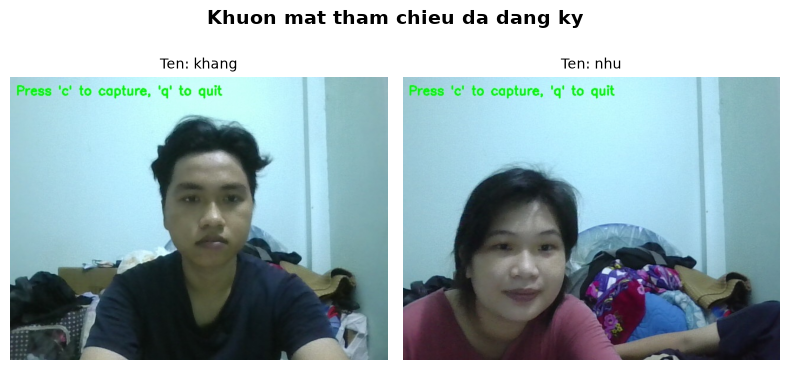

In [ ]:
def show_registered_faces(dataset_dir=DATASET_DIR):
    """Hien thi cac anh tham chieu da dang ky."""
    files = [f for f in os.listdir(dataset_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if not files:
        print('[!] Chua co anh tham chieu nao trong dataset/.')
        return
    
    n = len(files)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, fname in enumerate(files):
        img_bgr = cv2.imread(os.path.join(dataset_dir, fname))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        name = os.path.splitext(fname)[0]
        axes[i].imshow(img_rgb)
        axes[i].set_title(f'Ten: {name}', fontsize=10)
        axes[i].axis('off')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Khuon mat tham chieu da dang ky', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Luu anh
    save_path = os.path.join(OUTPUT_DIR, 'reference_faces.png')
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    print(f'[OK] Da luu anh vao: {save_path}')
    plt.show()


show_registered_faces()

---
## Phần 8: Kiểm Tra Nhanh Similarity Giữa Các Ảnh Tham Chiếu

Tính similarity chéo giữa các khuôn mặt đã đăng ký để kiểm tra chất lượng embedding.

In [ ]:
if len(reference_embeddings) >= 2:
    names = list(reference_embeddings.keys())
    print('Ma tran Cosine Similarity giua cac khuon mat tham chieu:')
    print('='*60)
    print(f'{"":15s}', end='')
    for name in names:
        print(f'{name:15s}', end='')
    print()
    print('-'*60)
    
    for name_a in names:
        print(f'{name_a:15s}', end='')
        for name_b in names:
            sim = np.dot(reference_embeddings[name_a], reference_embeddings[name_b])
            print(f'{sim:<15.4f}', end='')
        print()
    print('='*60)
    print('Ghi chu: Duong cheo = 1.0 (cung anh), cac o con lai < 0.7 la tot (khac nguoi)')
else:
    print('[!] Can it nhat 2 khuon mat tham chieu de so sanh cheo.')

Ma tran Cosine Similarity giua cac khuon mat tham chieu:
               khang          nhu            
------------------------------------------------------------
khang          1.0000         0.3377         
nhu            0.3377         1.0000         
Ghi chu: Duong cheo = 1.0 (cung anh), cac o con lai < 0.7 la tot (khac nguoi)


---
## Tổng Kết

| # | Phần | Tác Vụ | Thư Viện / Hàm Chính |
|---|------|--------|----------------------|
| 1 | Phần 1 | Truy cập webcam, chụp ảnh tham chiếu | `cv2.VideoCapture`, `cv2.imwrite` |
| 2 | Phần 2 | Khởi tạo MTCNN + FaceNet | `MTCNN`, `InceptionResnetV1` |
| 3 | Phần 3 | Trích xuất embedding (512 chiều) | `extract_embedding()` |
| 4 | Phần 4 | Đăng ký khuôn mặt tham chiếu | `register_reference_faces()` |
| 5 | Phần 5 | So khớp cosine similarity | `match_face()` |
| 6 | Phần 6 | Nhận diện thời gian thực | `run_recognition()` |
| 7 | Phần 7 | Hiển thị ảnh tham chiếu | `show_registered_faces()` |
| 8 | Phần 8 | Ma trận similarity chéo | `np.dot()` |

### Ngưỡng Nhận Diện

| Ngưỡng Cosine Similarity | Kết Quả | Màu Hiển Thị |
|--------------------------|---------|-------------|
| > 0.7 | Matched: &lt;Tên&gt; | Xanh lá |
| ≤ 0.7 | Unknown | Đỏ |

### Công Thức Chính

$$\text{similarity}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|} = A \cdot B \quad (\text{vì } \|A\| = \|B\| = 1)$$

### Lưu Ý Quan Trọng
- FaceNet cần ảnh khuôn mặt **160×160** pixels, định dạng **RGB**
- MTCNN cần ảnh đầu vào là **RGB** (chuyển từ BGR của OpenCV)
- Embedding phải được **chuẩn hóa L2** trước khi tính similarity
- Sử dụng `torch.no_grad()` để tăng tốc và tiết kiệm bộ nhớ
- Đảm bảo đủ ánh sáng để MTCNN phát hiện khuôn mặt chính xác